<a href="https://colab.research.google.com/github/vanefdzloera/VERANO-IA-2026/blob/main/Final_Project/PIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Artificial Intelligence final project

*   Alexa Gutiérrez Salgado 2114666
*   Claudia Vanessa Fernandez Loera 2094781

Hora clase: V4-V6


## **Libraries**

Se importan las librerias necesarias para el proyecto. Se utiliza TensorFlow y Keras para construir y entrenar la red neuronal, el openCV para leer y poder editar las fotografías y las librerías como Pandas, NumPy y Scikt-learn para manipular los datos. Matplotlib para graficar los resultados visualmente.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os
import kagglehub
from sklearn.model_selection import train_test_split

## **Preprocessing**

Se preparan las imágenes antes de dárselas a la red neuronal. Se descarga el dataset HAM10000 y se leen las 7 clases de lesiones. Después, se editan cada una de las 10,000 imagenes, corrigiendo su color y redimensionamos a una resolución de 128x128 pixeles.

In [ ]:
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


In [ ]:
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
metadata = pd.read_csv(path + '/HAM10000_metadata.csv')

In [ ]:
clases = metadata['dx'].unique()
diccionario = {clase: i for i, clase in enumerate(clases)}
print(clases)

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [ ]:
clases = list(clases)
imagenes = []
etiquetas = []

In [ ]:
for _, row in metadata.iterrows():
    nombre = row['image_id'] + '.jpg'
    ruta1 = path + '/HAM10000_images_part_1/' + nombre
    ruta2 = path + '/HAM10000_images_part_2/' + nombre

    img = cv2.imread(ruta1) if os.path.exists(ruta1) else cv2.imread(ruta2)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resize_final = cv2.resize(img_rgb, (128, 128))
    imagenes.append(img_resize_final)
    etiquetas.append(diccionario[row['dx']])

In [ ]:
X = np.array(imagenes)
y = np.array(etiquetas)

Finalmmente, divimos los datos (80% para entrenar la red y 20% para evaluarla) y normalizamos el valor de los píxeles dividiéndolor entre 255 para que el modelo provese la información matematicamente de forma más eficiente

In [ ]:
train_images, test_images, train_labels, test_labels = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
print(train_images.shape)
print(len(train_labels))
print(train_labels)

(8012, 128, 128, 3)
8012
[1 1 1 ... 1 0 1]


In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
file = path + '/HAM10000_images_part_1/ISIC_0027419.jpg'
test_image = cv2.imread(file)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

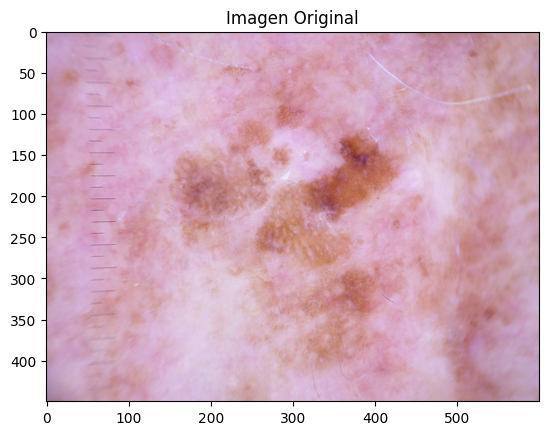

In [ ]:
plt.imshow(test_image)
plt.title("Imagen Original")
plt.show()

In [ ]:
img_resized = cv2.resize(test_image, (128, 128))

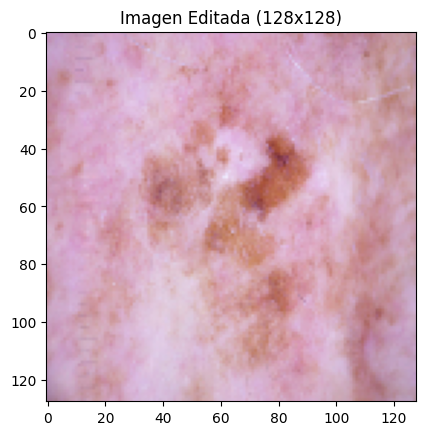

In [ ]:
os.makedirs('/content/Pruebas_PIA', exist_ok=True)
plt.imshow(img_resized)
plt.title("Imagen Editada (128x128)")
plt.savefig("/content/Pruebas_PIA/abc.png")
plt.show()

## **CNN Training**

Se construye la arquitectura de nuestra Red Neuonal Convolucional. Se utiliza una estructura secuencial con múltiples capas Conv2D y MaxPooling2D que se encargan de escanear las imagenes de 128x128 para extraer características visuales.

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Se aplanan los datos y se pasan por capas densas que toman la desición final para clasificar la imagen en una de las 7 posibles enfermedades.

In [ ]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(7, activation='softmax'))

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 519ms/step - accuracy: 0.6675 - loss: 1.0250 - val_accuracy: 0.6780 - val_loss: 0.9530
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 140s 512ms/step - accuracy: 0.6774 - loss: 0.9051 - val_accuracy: 0.6740 - val_loss: 0.9020
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 137s 494ms/step - accuracy: 0.6861 - loss: 0.8708 - val_accuracy: 0.6700 - val_loss: 0.9267
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 125s 496ms/step - accuracy: 0.7003 - loss: 0.8192 - val_accuracy: 0.6980 - val_loss: 0.8596
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 514ms/step - accuracy: 0.7207 - loss: 0.7605 - val_accuracy: 0.6995 - val_loss: 0.8244
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 139s 504ms/step - accuracy: 0.7317 - loss: 0.7245 - val_accuracy: 0.6990 - val_loss: 0.8187
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 144s 513ms/step - accuracy: 0.7465 - loss: 0.6980 - val_accuracy: 0.7224 - val_loss: 0.7424
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 511ms/step - accuracy: 0.7622 -

## **10 Predictions**

Se toman las primeras 10 imágenes del grupo y le pedimos a la red neuronal ya entrenada que las diagnostique. El código compara la predicción matemática del modelo contra la etiqueta verdadera proporcionada por el dataset original.

In [ ]:
predictions = model.predict(test_images)

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step


In [ ]:
print("Resultados de 10 Predicciones")
for i in range(10):
    indice_predicho = np.argmax(predictions[i])
    indice_real = test_labels[i]

    x = clases[indice_predicho]
    y = clases[indice_real]

    print("La red dice que la imagen " + str(i) + " es clase " + x + " y la clase verdadera es: " + y)

Resultados de 10 Predicciones
La red dice que la imagen 0 es clase bkl y la clase verdadera es: mel
La red dice que la imagen 1 es clase nv y la clase verdadera es: nv
La red dice que la imagen 2 es clase akiec y la clase verdadera es: mel
La red dice que la imagen 3 es clase nv y la clase verdadera es: bkl
La red dice que la imagen 4 es clase nv y la clase verdadera es: nv
La red dice que la imagen 5 es clase bkl y la clase verdadera es: nv
La red dice que la imagen 6 es clase nv y la clase verdadera es: nv
La red dice que la imagen 7 es clase nv y la clase verdadera es: nv
La red dice que la imagen 8 es clase bkl y la clase verdadera es: mel
La red dice que la imagen 9 es clase nv y la clase verdadera es: nv


## **Plot of training accuracy vs validation accuracy**

Una vez que el entrenamiento finaliza, se evaluó el desempeo del modelo graficando su precisión.

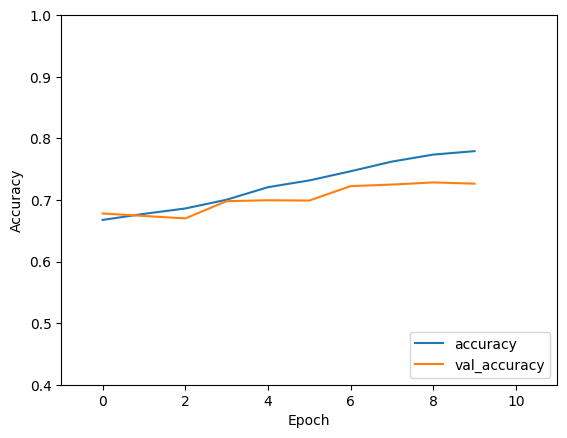

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.4, 1])
plt.xlim([-1, 11])
plt.legend(loc='lower right')
plt.show()

En la gráfica comparamos qué tan bien clasifica la red las imágenes que ya estudió versus qué tan bien clasifica el 20% de las imágenes nuevas que nunva había visto. Lo que permite comprobar de manera senilla que la red realmente está aprendiendo a diagnosticar y no solo memorizando las fotos.

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

63/63 - 9s - 142ms/step - accuracy: 0.7264 - loss: 0.8242
